# Evaporator Optimization: Diverse Data + KKT Conditioning

This notebook demonstrates generating **diverse training data** (like real plant historian data) while using **full KKT conditions** for the target problem to identify optimal solutions.

**Key approach:**
1. **Diverse data generation**: Solve feasibility problems with **varied constraint bounds** (via LHS)
   - X2_min varied in [30, 40] (around target 35.5)
   - P100_max varied in [300, 400] (around target 400)
2. **Compute KKT residuals for TARGET problem**: For each point, compute KKT residuals using the **target constraints** (X2_min=35.5, P100_max=400)
3. **Condition on full KKT = 0**: Sample points that are optimal for the target problem

**Why this works:**
- Training data is diverse (realistic plant operations)
- KKT residuals tell us "how far from target optimal" each point is
- Points near the target optimal have small KKT residuals
- Conditioning on KKT=0 selects the optimal region

## System Information

In [129]:
import sys
import platform
import time
import psutil
import os

print("System Information")
print("=" * 70)
print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"CPU count: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical")
print(f"Total memory: {psutil.virtual_memory().total / (1024**3):.2f} GB")
print("=" * 70)

# Key package versions
print("\nKey Library Versions:")
print("-" * 70)
packages = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sklearn', 'sklearn'),
    ('torch', 'torch'),
    ('gmr', 'gmr'),
]

for pkg_name, import_name in packages:
    try:
        mod = __import__(pkg_name)
        version = getattr(mod, '__version__', 'unknown')
        print(f"{pkg_name:<20} {version}")
    except ImportError:
        print(f"{pkg_name:<20} NOT INSTALLED")

print("-" * 70)

# Initialize timing and memory tracking
_start_time = time.time()
_process = psutil.Process(os.getpid())
_start_memory_mb = _process.memory_info().rss / (1024 * 1024)

print(f"\nNotebook execution started: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"Initial memory usage: {_start_memory_mb:.2f} MB")
print("=" * 70)

System Information
Python version: 3.13.2 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:35) [Clang 14.0.6 ]
Platform: macOS-15.7.3-arm64-arm-64bit-Mach-O
Processor: arm
CPU count: 10 physical, 10 logical
Total memory: 32.00 GB

Key Library Versions:
----------------------------------------------------------------------
numpy                2.2.5
scipy                1.15.2
matplotlib           3.10.1
sklearn              1.6.1
torch                2.9.1
gmr                  1.6.2
----------------------------------------------------------------------

Notebook execution started: 2026-01-18 21:35:25
Initial memory usage: 878.41 MB


In [130]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Force CPU for JAX
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
from scipy.optimize import minimize
from scipy.stats.qmc import LatinHypercube, scale as qmc_scale
from tqdm.auto import tqdm

# Import reusable utilities
from generative_optimization import (
    generate_samples,
    best_gmm,
    cluster_stats,
    ConditionalFlowMatching
)

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.size'] = 10

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

print("Setup complete")

Setup complete


## Problem Definition

The forced-circulation evaporator optimization problem is from Newell & Lee (1989).

**Reference:** R.B. Newell and P.L. Lee, *Applied Process Control: A Case Study*, Prentice Hall, 1989.

**16 Decision Variables:**
- $F_1, F_2, F_3, F_4, F_5$: Flow rates (kg/min)
- $X_2$: Product composition (%)
- $T_2, T_3$: Temperatures (°C)
- $P_2$: Separator pressure (kPa)
- $F_{100}$: Steam flow rate (kg/min)
- $T_{100}$: Steam temperature (°C)
- $P_{100}$: Steam pressure (kPa)
- $Q_{100}$: Heat duty (kW)
- $F_{200}$: Cooling water flow (kg/min)
- $T_{201}$: Cooling water outlet temperature (°C)
- $Q_{200}$: Condenser duty (kW)

**Objective:** Minimize cost
$$\text{Cost} = 600F_{100} + 0.6F_{200} + 1.009(F_2 + F_3) + 0.2F_1 - 4800F_2$$

**12 Equality Constraints:** Mass and energy balances (steady state)

**Inequality Constraints (handled via barrier method):**
- $X_2 \geq X_2^{\min}$ (varied: 33% to 38%)
- $P_{100} \leq P_{100}^{\max}$ (varied: 260 to 400 kPa)
- $40 \leq P_2 \leq 80$ kPa (fixed)

**Barrier Method for Inequalities:**
$$\phi(x) = \sum_i e_i(x)^2 - \mu \sum_{j \in \mathcal{I}} \log(c_j(x))$$

where $e_i(x)$ are equality constraint residuals and $c_j(x) \geq 0$ are inequality constraints.

In [131]:
# Variable names and indices
# 0:F1, 1:F2, 2:F3, 3:F4, 4:F5, 5:X2, 6:T2, 7:T3, 8:P2, 9:F100,
# 10:T100, 11:P100, 12:Q100, 13:F200, 14:T201, 15:Q200

NAMES = ['F1', 'F2', 'F3', 'F4', 'F5', 'X2', 'T2', 'T3', 'P2', 'F100',
         'T100', 'P100', 'Q100', 'F200', 'T201', 'Q200']

# Constants (disturbances / fixed)
X1 = 5.0    # %
T1 = 40.0   # °C
T200 = 25.0 # °C

# Base bounds (lb/ub) - physical limits only, not optimization constraints
lb_base = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 20, 40, 40, 40, 0.1, 100, 102, 300, 0.1, 20, 200], dtype=float)
ub_base = np.array([20, 20, 100, 20, 20, 40, 100, 100, 80, 20, 300, 400, 500, 400, 100, 500], dtype=float)

# Literature optimum (for comparison only - NOT used for training)
x_opt_lit = np.array([
    9.469, 1.334, 24.721, 8.135, 8.135, 35.500, 88.400, 81.066, 51.412,
    9.434, 151.520, 400.000, 345.292, 217.738, 45.550, 313.210
], dtype=float)

def objective(x):
    """Cost function to minimize (economic objective)."""
    F1, F2, F3 = x[0], x[1], x[2]
    F100, F200 = x[9], x[13]
    return 600*F100 + 0.6*F200 + 1.009*(F2 + F3) + 0.2*F1 - 4800*F2

def equalities(x):
    """12 equality constraints (mass and energy balances)."""
    F1, F2, F3, F4, F5, X2, T2, T3, P2, F100, T100, P100, Q100, F200, T201, Q200 = x
    
    eq = np.zeros(12)
    eq[0] = (F1 - F4 - F2) / 20.0                                    # dL2/dt = 0
    eq[1] = (F1*X1 - F2*X2) / 20.0                                   # dX2/dt = 0
    eq[2] = (F4 - F5) / 4.0                                          # dP2/dt = 0
    eq[3] = 0.5616*P2 + 0.3126*X2 + 48.43 - T2                       # T2 correlation
    eq[4] = 0.507*P2 + 55.0 - T3                                     # T3 correlation
    eq[5] = (Q100 - 0.07*F1*(T2 - T1)) / 38.5 - F4                   # F4 energy balance
    eq[6] = 0.1538*P100 + 90.0 - T100                                # T100 correlation
    eq[7] = 0.16*(F1 + F3)*(T100 - T2) - Q100                        # Heater duty
    eq[8] = Q100 / 36.6 - F100                                       # Steam flow
    ratio = (T3 - T200) / (0.14*F200 + 6.84)
    eq[9] = 0.9576*F200*ratio - Q200                                 # Condenser duty
    eq[10] = T200 + 13.68*ratio - T201                               # Cooling water outlet temp
    eq[11] = Q200 / 38.5 - F5                                        # Condensate flow
    return eq

def max_constraint_violation(x):
    """Compute maximum equality constraint violation."""
    return np.max(np.abs(equalities(x)))

print("Problem functions defined")
print(f"Literature solution cost: {objective(x_opt_lit):.4f}")
print(f"Literature solution max constraint violation: {max_constraint_violation(x_opt_lit):.2e}")

Problem functions defined
Literature solution cost: -583.9739
Literature solution max constraint violation: 1.48e-03


## KKT Conditions for the TARGET Problem

**Target optimization problem:**
```
minimize   J(x)
subject to e(x) = 0        (12 equality constraints)
           X2 >= 35.5      (target lower bound)
           40 <= P2 <= 80  (fixed bounds)
           P100 <= 400     (target upper bound)
```

**Barrier-augmented Lagrangian for TARGET:**
$$L(x) = J(x) - \mu \left[ \log(X_2 - 35.5) + \log(P_2 - 40) + \log(80 - P_2) + \log(400 - P_{100}) \right]$$

**KKT conditions (what we condition on):**
1. **Stationarity**: $\nabla_x L = \nabla J - \mu \sum_{j} \frac{\nabla c_j}{c_j} = 0$ (16 equations)
2. **Equality feasibility**: $e(x) = 0$ (12 equations)

Total: **28 KKT residuals** to condition on.

**Key insight:** Training data comes from varied constraint configurations (diverse), but KKT residuals are always computed for the **TARGET problem** (X2_min=35.5, P100_max=400).

In [132]:
# TARGET problem constraints (what we want to optimize for)
TARGET_X2_MIN = 35.5    # Target lower bound on X2
TARGET_P100_MAX = 400.0  # Target upper bound on P100
MU_BARRIER = 0.1         # Barrier parameter


def barrier_feasibility_objective(x, X2_min, P100_max, mu=0.1):
    """
    Barrier-augmented FEASIBILITY objective (for data generation).
    
    phi(x) = sum(eq^2) - mu * sum(log(slacks))
    
    This finds feasible points WITHOUT optimizing J.
    """
    # Equality constraint penalty
    eq = equalities(x)
    eq_penalty = np.sum(eq**2)
    
    X2, P2, P100 = x[5], x[8], x[11]
    eps = 1e-8
    barrier = 0.0
    
    if X2 - X2_min > eps:
        barrier -= mu * np.log(X2 - X2_min)
    else:
        return 1e10
    
    if P2 - 40.0 > eps:
        barrier -= mu * np.log(P2 - 40.0)
    else:
        return 1e10
    
    if 80.0 - P2 > eps:
        barrier -= mu * np.log(80.0 - P2)
    else:
        return 1e10
    
    if P100_max - P100 > eps:
        barrier -= mu * np.log(P100_max - P100)
    else:
        return 1e10
    
    return eq_penalty + barrier


def compute_kkt_residuals_target(x, mu=MU_BARRIER):
    """
    Compute full KKT residuals for the TARGET problem.
    
    These residuals are computed using TARGET constraints (X2>=35.5, P100<=400),
    NOT the varied constraints used for data generation.
    
    Returns
    -------
    eq_res : array (12,)
        Equality constraint residuals
    grad_res : array (16,)
        Stationarity residuals (gradient of barrier Lagrangian for TARGET)
    """
    # 1. Equality constraint residuals (always same)
    eq_res = equalities(x)
    
    # 2. Stationarity residuals for TARGET problem
    # ∇L = ∇J - μ * Σ(∇cⱼ/cⱼ) where cⱼ are TARGET constraints
    
    # Gradient of economic objective
    grad_J = np.zeros(16)
    grad_J[0] = 0.2       # ∂J/∂F1
    grad_J[1] = 1.009 - 4800  # ∂J/∂F2
    grad_J[2] = 1.009     # ∂J/∂F3
    grad_J[9] = 600       # ∂J/∂F100
    grad_J[13] = 0.6      # ∂J/∂F200
    
    # Gradient of barrier terms for TARGET constraints
    X2, P2, P100 = x[5], x[8], x[11]
    grad_barrier = np.zeros(16)
    eps = 1e-8
    
    # ∂/∂X2: -μ / (X2 - 35.5)  [TARGET constraint]
    slack_X2 = X2 - TARGET_X2_MIN
    if slack_X2 > eps:
        grad_barrier[5] = -mu / slack_X2
    else:
        grad_barrier[5] = -1e6  # Large penalty if infeasible for TARGET
    
    # ∂/∂P2: -μ / (P2 - 40) + μ / (80 - P2)
    slack_P2_lb = P2 - 40.0
    slack_P2_ub = 80.0 - P2
    if slack_P2_lb > eps and slack_P2_ub > eps:
        grad_barrier[8] = -mu / slack_P2_lb + mu / slack_P2_ub
    else:
        grad_barrier[8] = -1e6  # Large penalty if infeasible
    
    # ∂/∂P100: +μ / (400 - P100)  [TARGET constraint]
    slack_P100 = TARGET_P100_MAX - P100
    if slack_P100 > eps:
        grad_barrier[11] = mu / slack_P100
    else:
        grad_barrier[11] = 1e6  # Large penalty if infeasible for TARGET
    
    # Stationarity: ∇J + ∇barrier = 0  →  residual = ∇J + ∇barrier
    grad_res = grad_J + grad_barrier
    
    return eq_res, grad_res


def check_inequalities(x, X2_min, P100_max):
    """Check inequality constraint satisfaction."""
    return {
        'X2 >= X2_min': x[5] - X2_min,
        'P2 >= 40': x[8] - 40.0,
        'P2 <= 80': 80.0 - x[8],
        'P100 <= P100_max': P100_max - x[11]
    }


print("Functions defined:")
print("  - barrier_feasibility_objective(): For generating diverse data")
print("  - compute_kkt_residuals_target(): Computes KKT residuals for TARGET problem")
print(f"\nTARGET problem constraints:")
print(f"  X2 >= {TARGET_X2_MIN}")
print(f"  P100 <= {TARGET_P100_MAX}")
print(f"  Barrier parameter μ = {MU_BARRIER}")

Functions defined:
  - barrier_feasibility_objective(): For generating diverse data
  - compute_kkt_residuals_target(): Computes KKT residuals for TARGET problem

TARGET problem constraints:
  X2 >= 35.5
  P100 <= 400.0
  Barrier parameter μ = 0.1


## Reference Solution with Scipy

We solve the original problem (with nominal constraints) for reference.

In [133]:
# Original problem constraints
def inequalities_original(x):
    """Original 3 inequality constraints (>=0)."""
    X2, P2 = x[5], x[8]
    ineq = np.zeros(3)
    ineq[0] = X2 - 35.5      # X2 >= 35.5
    ineq[1] = P2 - 40.0      # P2 >= 40
    ineq[2] = 80.0 - P2      # P2 <= 80
    return ineq

# Set up bounds for original problem
lb_orig = lb_base.copy()
ub_orig = ub_base.copy()

# Initial guess
x0 = np.array([10, 1, 25, 8, 8, 36, 85, 80, 55, 9, 150, 350, 350, 200, 50, 300], dtype=float)

# Solve original optimization problem
scipy_constraints = [
    {'type': 'eq', 'fun': equalities},
    {'type': 'ineq', 'fun': inequalities_original}
]
res = minimize(objective, x0, bounds=list(zip(lb_orig, ub_orig)), constraints=scipy_constraints)

print("Scipy Solution (SLSQP) - Original Problem")
print("=" * 70)
print(f"Success: {res.success} | Objective (Cost): {res.fun:.4f}")
print(f"Max equality constraint violation: {max_constraint_violation(res.x):.2e}")

# Check inequality constraints
ineq_check = check_inequalities(res.x, 35.5, 400.0)
print(f"\nInequality constraint satisfaction:")
for name, val in ineq_check.items():
    status = 'OK' if val >= 0 else 'VIOLATED'
    print(f"  {name}: {val:.4f} ({status})")

# Store scipy solution for comparison
scipy_solution = res.x.copy()
scipy_cost = res.fun

Scipy Solution (SLSQP) - Original Problem
Success: True | Objective (Cost): -582.2331
Max equality constraint violation: 5.83e-07

Inequality constraint satisfaction:
  X2 >= X2_min: -0.0000 (VIOLATED)
  P2 >= 40: 11.4119 (OK)
  P2 <= 80: 28.5881 (OK)
  P100 <= P100_max: 0.0000 (OK)


<cell_type>markdown</cell_type>---

# Diverse Data Generation: Operating Modes Mixture

Real plant historian data includes **multiple operating modes**:

1. **Mode 1 - Normal Operations (~60%)**: Random feasible points from solving feasibility problems with varied constraints. Represents day-to-day operations.

2. **Mode 2 - Efficiency Operations (~30%)**: Cost-optimal points from solving actual optimization problems with varied constraints. Represents periods when the plant operates in cost-minimization mode.

3. **Mode 3 - Boundary Exploration (~10%)**: Feasibility problems with tight constraint bands near boundaries. Represents commissioning, testing, and upset recovery.

**Why this approach works:**
- Mode 1 provides diversity (random feasible operations)
- Mode 2 provides optimal-region coverage (cost-optimized operations naturally reach constraint boundaries)
- Mode 3 provides boundary coverage (testing operations)
- All modes are **realistically motivated** — not arbitrary bias toward a known answer
- When we condition on KKT=0 for TARGET, the model can interpolate to the optimal because training data includes nearby points

In [134]:
# Constraint variation ranges for the THREE operating modes

# Mode 1: Normal Operations - wide ranges for diverse feasibility data
MODE1_X2_MIN_RANGE = (30.0, 40.0)      # Wide range for X2 lower bound
MODE1_P100_MAX_RANGE = (300.0, 400.0)  # Wide range for P100 upper bound

# Mode 2: Efficiency Operations - ranges that include the target optimal region
MODE2_X2_MIN_RANGE = (33.0, 38.0)      # Includes target 35.5
MODE2_P100_MAX_RANGE = (350.0, 400.0)  # Includes target 400

# Mode 3: Boundary Exploration - tight ranges near target constraints
MODE3_X2_MIN_RANGE = (35.0, 36.5)      # Near target 35.5
MODE3_P100_MAX_RANGE = (385.0, 400.0)  # Near target 400

print("Operating Modes Configuration:")
print("=" * 70)
print(f"\nMode 1 - Normal Operations (feasibility, ~60% of data):")
print(f"  X2_min ∈ [{MODE1_X2_MIN_RANGE[0]}, {MODE1_X2_MIN_RANGE[1]}]")
print(f"  P100_max ∈ [{MODE1_P100_MAX_RANGE[0]}, {MODE1_P100_MAX_RANGE[1]}]")

print(f"\nMode 2 - Efficiency Operations (optimization, ~30% of data):")
print(f"  X2_min ∈ [{MODE2_X2_MIN_RANGE[0]}, {MODE2_X2_MIN_RANGE[1]}]")
print(f"  P100_max ∈ [{MODE2_P100_MAX_RANGE[0]}, {MODE2_P100_MAX_RANGE[1]}]")

print(f"\nMode 3 - Boundary Exploration (feasibility near boundaries, ~10% of data):")
print(f"  X2_min ∈ [{MODE3_X2_MIN_RANGE[0]}, {MODE3_X2_MIN_RANGE[1]}]")
print(f"  P100_max ∈ [{MODE3_P100_MAX_RANGE[0]}, {MODE3_P100_MAX_RANGE[1]}]")

print(f"\nTARGET problem: X2 >= {TARGET_X2_MIN}, P100 <= {TARGET_P100_MAX}")

Operating Modes Configuration:

Mode 1 - Normal Operations (feasibility, ~60% of data):
  X2_min ∈ [30.0, 40.0]
  P100_max ∈ [300.0, 400.0]

Mode 2 - Efficiency Operations (optimization, ~30% of data):
  X2_min ∈ [33.0, 38.0]
  P100_max ∈ [350.0, 400.0]

Mode 3 - Boundary Exploration (feasibility near boundaries, ~10% of data):
  X2_min ∈ [35.0, 36.5]
  P100_max ∈ [385.0, 400.0]

TARGET problem: X2 >= 35.5, P100 <= 400.0


In [135]:
def generate_normal_operations(n_configs=300, n_starts_per_config=10, mu=0.1, seed=42):
    """
    Mode 1: Normal Operations - Feasibility problems with varied constraints.
    
    Represents day-to-day plant operations at various feasible points.
    Solves: minimize ||e(x)||² subject to barrier-augmented inequalities
    """
    np.random.seed(seed)
    
    solutions = []
    costs = []
    eq_residuals = []
    grad_residuals = []
    eq_violations = []
    
    # Generate constraint configurations using LHS
    config_sampler = LatinHypercube(d=2, seed=seed)
    config_samples = config_sampler.random(n=n_configs)
    X2_min_values = MODE1_X2_MIN_RANGE[0] + config_samples[:, 0] * (MODE1_X2_MIN_RANGE[1] - MODE1_X2_MIN_RANGE[0])
    P100_max_values = MODE1_P100_MAX_RANGE[0] + config_samples[:, 1] * (MODE1_P100_MAX_RANGE[1] - MODE1_P100_MAX_RANGE[0])
    
    print(f"Mode 1: Generating normal operations data...")
    print(f"  Configs: {n_configs}, Starts/config: {n_starts_per_config}")
    
    pbar = tqdm(total=n_configs * n_starts_per_config, desc="Mode 1: Normal ops")
    
    for X2_min, P100_max in zip(X2_min_values, P100_max_values):
        # Generate random starting points
        lb_start = lb_base.copy()
        ub_start = ub_base.copy()
        lb_start[5] = max(X2_min + 0.5, lb_base[5])
        ub_start[5] = min(ub_base[5], X2_min + 5.0)
        lb_start[8] = 42.0
        ub_start[8] = 78.0
        ub_start[11] = min(P100_max - 5.0, ub_base[11])
        
        # Check bounds validity
        if any(lb_start[i] >= ub_start[i] for i in range(16)):
            pbar.update(n_starts_per_config)
            continue
        
        sampler = LatinHypercube(d=16, seed=int(X2_min*100 + P100_max))
        starts = qmc_scale(sampler.random(n=n_starts_per_config), lb_start, ub_start)
        
        for x0 in starts:
            try:
                def feas_obj(x):
                    return barrier_feasibility_objective(x, X2_min, P100_max, mu)
                
                res = minimize(feas_obj, x0, bounds=list(zip(lb_base, ub_base)),
                             method='L-BFGS-B', options={'maxiter': 500})
                
                x_sol = res.x
                eq_viol = max_constraint_violation(x_sol)
                ineq_check = check_inequalities(x_sol, X2_min, P100_max)
                all_ineq_ok = all(v > -0.01 for v in ineq_check.values())
                
                if eq_viol < 0.5 and all_ineq_ok:
                    eq_res, grad_res = compute_kkt_residuals_target(x_sol, mu)
                    solutions.append(x_sol)
                    costs.append(objective(x_sol))
                    eq_residuals.append(eq_res)
                    grad_residuals.append(grad_res)
                    eq_violations.append(eq_viol)
            except:
                pass
            pbar.update(1)
    
    pbar.close()
    
    solutions = np.array(solutions) if solutions else np.empty((0, 16))
    costs = np.array(costs) if costs else np.empty(0)
    eq_residuals = np.array(eq_residuals) if eq_residuals else np.empty((0, 12))
    grad_residuals = np.array(grad_residuals) if grad_residuals else np.empty((0, 16))
    
    print(f"  Generated {len(solutions)} solutions")
    if len(costs) > 0:
        print(f"  Objective range: [{costs.min():.2f}, {costs.max():.2f}]")
    
    return solutions, costs, eq_residuals, grad_residuals


def generate_efficiency_operations(n_configs=150, n_starts_per_config=5, seed=123):
    """
    Mode 2: Efficiency Operations - Optimization problems with varied constraints.
    
    Represents periods when plant operates in cost-minimization mode.
    Solves: minimize J(x) subject to e(x)=0, inequalities
    This naturally produces points near constraint boundaries (where optima lie).
    """
    np.random.seed(seed)
    
    solutions = []
    costs = []
    eq_residuals = []
    grad_residuals = []
    eq_violations = []
    
    # Generate constraint configurations using LHS
    config_sampler = LatinHypercube(d=2, seed=seed)
    config_samples = config_sampler.random(n=n_configs)
    X2_min_values = MODE2_X2_MIN_RANGE[0] + config_samples[:, 0] * (MODE2_X2_MIN_RANGE[1] - MODE2_X2_MIN_RANGE[0])
    P100_max_values = MODE2_P100_MAX_RANGE[0] + config_samples[:, 1] * (MODE2_P100_MAX_RANGE[1] - MODE2_P100_MAX_RANGE[0])
    
    print(f"\nMode 2: Generating efficiency operations data...")
    print(f"  Configs: {n_configs}, Starts/config: {n_starts_per_config}")
    
    pbar = tqdm(total=n_configs * n_starts_per_config, desc="Mode 2: Efficiency ops")
    
    for X2_min, P100_max in zip(X2_min_values, P100_max_values):
        # Generate random starting points
        lb_start = lb_base.copy()
        ub_start = ub_base.copy()
        lb_start[5] = X2_min + 0.1
        lb_start[8] = 41.0
        ub_start[8] = 79.0
        ub_start[11] = P100_max - 0.1
        
        sampler = LatinHypercube(d=16, seed=int(X2_min*100 + P100_max + 1000))
        starts = qmc_scale(sampler.random(n=n_starts_per_config), lb_start, ub_start)
        
        for x0 in starts:
            try:
                # Define inequality constraints for this configuration
                def ineq_constraints(x, x2_min=X2_min, p100_max=P100_max):
                    return np.array([
                        x[5] - x2_min,      # X2 >= X2_min
                        x[8] - 40.0,        # P2 >= 40
                        80.0 - x[8],        # P2 <= 80
                        p100_max - x[11]    # P100 <= P100_max
                    ])
                
                constraints = [
                    {'type': 'eq', 'fun': equalities},
                    {'type': 'ineq', 'fun': lambda x, xm=X2_min, pm=P100_max: ineq_constraints(x, xm, pm)}
                ]
                
                # Solve ACTUAL optimization problem (minimize cost)
                res = minimize(objective, x0, bounds=list(zip(lb_base, ub_base)),
                             constraints=constraints, method='SLSQP',
                             options={'maxiter': 500, 'ftol': 1e-6})
                
                if res.success:
                    x_sol = res.x
                    eq_viol = max_constraint_violation(x_sol)
                    
                    if eq_viol < 0.1:
                        eq_res, grad_res = compute_kkt_residuals_target(x_sol, MU_BARRIER)
                        solutions.append(x_sol)
                        costs.append(objective(x_sol))
                        eq_residuals.append(eq_res)
                        grad_residuals.append(grad_res)
                        eq_violations.append(eq_viol)
            except:
                pass
            pbar.update(1)
    
    pbar.close()
    
    solutions = np.array(solutions) if solutions else np.empty((0, 16))
    costs = np.array(costs) if costs else np.empty(0)
    eq_residuals = np.array(eq_residuals) if eq_residuals else np.empty((0, 12))
    grad_residuals = np.array(grad_residuals) if grad_residuals else np.empty((0, 16))
    
    print(f"  Generated {len(solutions)} solutions")
    if len(costs) > 0:
        print(f"  Objective range: [{costs.min():.2f}, {costs.max():.2f}]")
        print(f"  X2 range: [{solutions[:, 5].min():.2f}, {solutions[:, 5].max():.2f}]")
        print(f"  P100 range: [{solutions[:, 11].min():.2f}, {solutions[:, 11].max():.2f}]")
    
    return solutions, costs, eq_residuals, grad_residuals


def generate_boundary_data(n_configs=50, n_starts_per_config=10, mu=0.1, seed=456):
    """
    Mode 3: Boundary Exploration - Feasibility near constraint boundaries.
    
    Represents commissioning, testing, and upset recovery operations.
    Solves feasibility with tight constraint bands near target boundaries.
    """
    np.random.seed(seed)
    
    solutions = []
    costs = []
    eq_residuals = []
    grad_residuals = []
    eq_violations = []
    
    # Generate constraint configurations using LHS
    config_sampler = LatinHypercube(d=2, seed=seed)
    config_samples = config_sampler.random(n=n_configs)
    X2_min_values = MODE3_X2_MIN_RANGE[0] + config_samples[:, 0] * (MODE3_X2_MIN_RANGE[1] - MODE3_X2_MIN_RANGE[0])
    P100_max_values = MODE3_P100_MAX_RANGE[0] + config_samples[:, 1] * (MODE3_P100_MAX_RANGE[1] - MODE3_P100_MAX_RANGE[0])
    
    print(f"\nMode 3: Generating boundary exploration data...")
    print(f"  Configs: {n_configs}, Starts/config: {n_starts_per_config}")
    
    pbar = tqdm(total=n_configs * n_starts_per_config, desc="Mode 3: Boundary exp")
    
    for X2_min, P100_max in zip(X2_min_values, P100_max_values):
        # Tight bounds to force solutions near boundaries
        lb_config = lb_base.copy()
        ub_config = ub_base.copy()
        
        # Force X2 to be near X2_min (tight band)
        lb_config[5] = X2_min + 0.01
        ub_config[5] = min(X2_min + 1.5, ub_base[5])
        
        # Force P100 to be near P100_max (tight band)
        lb_config[11] = max(P100_max - 15.0, lb_base[11])
        ub_config[11] = P100_max - 0.01
        
        lb_config[8] = 42.0
        ub_config[8] = 78.0
        
        # Check bounds validity
        if any(lb_config[i] >= ub_config[i] for i in range(16)):
            pbar.update(n_starts_per_config)
            continue
        
        sampler = LatinHypercube(d=16, seed=int(X2_min*100 + P100_max + 2000))
        starts = qmc_scale(sampler.random(n=n_starts_per_config), lb_config, ub_config)
        
        for x0 in starts:
            try:
                def feas_obj(x):
                    return barrier_feasibility_objective(x, X2_min, P100_max, mu)
                
                res = minimize(feas_obj, x0, bounds=list(zip(lb_config, ub_config)),
                             method='L-BFGS-B', options={'maxiter': 500})
                
                x_sol = res.x
                eq_viol = max_constraint_violation(x_sol)
                ineq_check = check_inequalities(x_sol, X2_min, P100_max)
                all_ineq_ok = all(v > -0.01 for v in ineq_check.values())
                
                if eq_viol < 0.5 and all_ineq_ok:
                    eq_res, grad_res = compute_kkt_residuals_target(x_sol, mu)
                    solutions.append(x_sol)
                    costs.append(objective(x_sol))
                    eq_residuals.append(eq_res)
                    grad_residuals.append(grad_res)
                    eq_violations.append(eq_viol)
            except:
                pass
            pbar.update(1)
    
    pbar.close()
    
    solutions = np.array(solutions) if solutions else np.empty((0, 16))
    costs = np.array(costs) if costs else np.empty(0)
    eq_residuals = np.array(eq_residuals) if eq_residuals else np.empty((0, 12))
    grad_residuals = np.array(grad_residuals) if grad_residuals else np.empty((0, 16))
    
    print(f"  Generated {len(solutions)} solutions")
    if len(costs) > 0:
        print(f"  Objective range: [{costs.min():.2f}, {costs.max():.2f}]")
        print(f"  X2 range: [{solutions[:, 5].min():.2f}, {solutions[:, 5].max():.2f}]")
        print(f"  P100 range: [{solutions[:, 11].min():.2f}, {solutions[:, 11].max():.2f}]")
    
    return solutions, costs, eq_residuals, grad_residuals


print("Data generation functions defined:")
print("  - generate_normal_operations(): Mode 1 - feasibility with varied constraints")
print("  - generate_efficiency_operations(): Mode 2 - optimization (cost minimization)")
print("  - generate_boundary_data(): Mode 3 - feasibility near boundaries")

Data generation functions defined:
  - generate_normal_operations(): Mode 1 - feasibility with varied constraints
  - generate_efficiency_operations(): Mode 2 - optimization (cost minimization)
  - generate_boundary_data(): Mode 3 - feasibility near boundaries


In [136]:
# Generate training data from ALL THREE operating modes
print("=" * 70)
print("GENERATING TRAINING DATA FROM THREE OPERATING MODES")
print("=" * 70)

# Mode 1: Normal Operations (~60% of data)
X_mode1, obj_mode1, eq_mode1, grad_mode1 = generate_normal_operations(
    n_configs=300, n_starts_per_config=10, mu=MU_BARRIER, seed=42
)

# Mode 2: Efficiency Operations (~30% of data)
X_mode2, obj_mode2, eq_mode2, grad_mode2 = generate_efficiency_operations(
    n_configs=150, n_starts_per_config=5, seed=123
)

# Mode 3: Boundary Exploration (~10% of data)
X_mode3, obj_mode3, eq_mode3, grad_mode3 = generate_boundary_data(
    n_configs=50, n_starts_per_config=10, mu=MU_BARRIER, seed=456
)

# Combine all modes
print("\n" + "=" * 70)
print("COMBINING ALL MODES")
print("=" * 70)

X_solutions = np.vstack([X_mode1, X_mode2, X_mode3])
obj_solutions = np.concatenate([obj_mode1, obj_mode2, obj_mode3])
eq_solutions = np.vstack([eq_mode1, eq_mode2, eq_mode3])
grad_solutions = np.vstack([grad_mode1, grad_mode2, grad_mode3])

# Compute violations for all
viol_solutions = np.array([max_constraint_violation(x) for x in X_solutions])

# Create mode labels for visualization
mode_labels = (
    ['Mode 1: Normal'] * len(X_mode1) + 
    ['Mode 2: Efficiency'] * len(X_mode2) + 
    ['Mode 3: Boundary'] * len(X_mode3)
)

print(f"\nTotal training data: {len(X_solutions)} samples")
print(f"  Mode 1 (Normal ops):      {len(X_mode1):5d} ({100*len(X_mode1)/len(X_solutions):.1f}%)")
print(f"  Mode 2 (Efficiency ops):  {len(X_mode2):5d} ({100*len(X_mode2)/len(X_solutions):.1f}%)")
print(f"  Mode 3 (Boundary exp):    {len(X_mode3):5d} ({100*len(X_mode3)/len(X_solutions):.1f}%)")

print(f"\nCombined data statistics:")
print(f"  Objective range: [{obj_solutions.min():.2f}, {obj_solutions.max():.2f}]")
print(f"  Objective mean:  {obj_solutions.mean():.2f}")
print(f"  Target optimal:  {scipy_cost:.2f}")
print(f"\n  X2 range:  [{X_solutions[:, 5].min():.2f}, {X_solutions[:, 5].max():.2f}] (target: {TARGET_X2_MIN})")
print(f"  P100 range: [{X_solutions[:, 11].min():.2f}, {X_solutions[:, 11].max():.2f}] (target: {TARGET_P100_MAX})")

GENERATING TRAINING DATA FROM THREE OPERATING MODES
Mode 1: Generating normal operations data...
  Configs: 300, Starts/config: 10


Mode 1: Normal ops: 100%|██████████| 3000/3000 [03:53<00:00, 12.82it/s]


  Generated 1323 solutions
  Objective range: [-5096.53, 2804.94]

Mode 2: Generating efficiency operations data...
  Configs: 150, Starts/config: 5


Mode 2: Efficiency ops: 100%|██████████| 750/750 [00:07<00:00, 105.36it/s]


  Generated 749 solutions
  Objective range: [-1248.49, -146.02]
  X2 range: [33.03, 37.97]
  P100 range: [350.01, 399.91]

Mode 3: Generating boundary exploration data...
  Configs: 50, Starts/config: 10


Mode 3: Boundary exp: 100%|██████████| 500/500 [00:53<00:00,  9.35it/s]

  Generated 500 solutions
  Objective range: [-6102.93, 103.58]
  X2 range: [36.52, 37.97]
  P100 range: [370.03, 391.50]

COMBINING ALL MODES

Total training data: 2572 samples
  Mode 1 (Normal ops):       1323 (51.4%)
  Mode 2 (Efficiency ops):    749 (29.1%)
  Mode 3 (Boundary exp):      500 (19.4%)

Combined data statistics:
  Objective range: [-6102.93, 2804.94]
  Objective mean:  -122.83
  Target optimal:  -582.23

  X2 range:  [33.03, 40.00] (target: 35.5)
  P100 range: [132.40, 399.91] (target: 400.0)


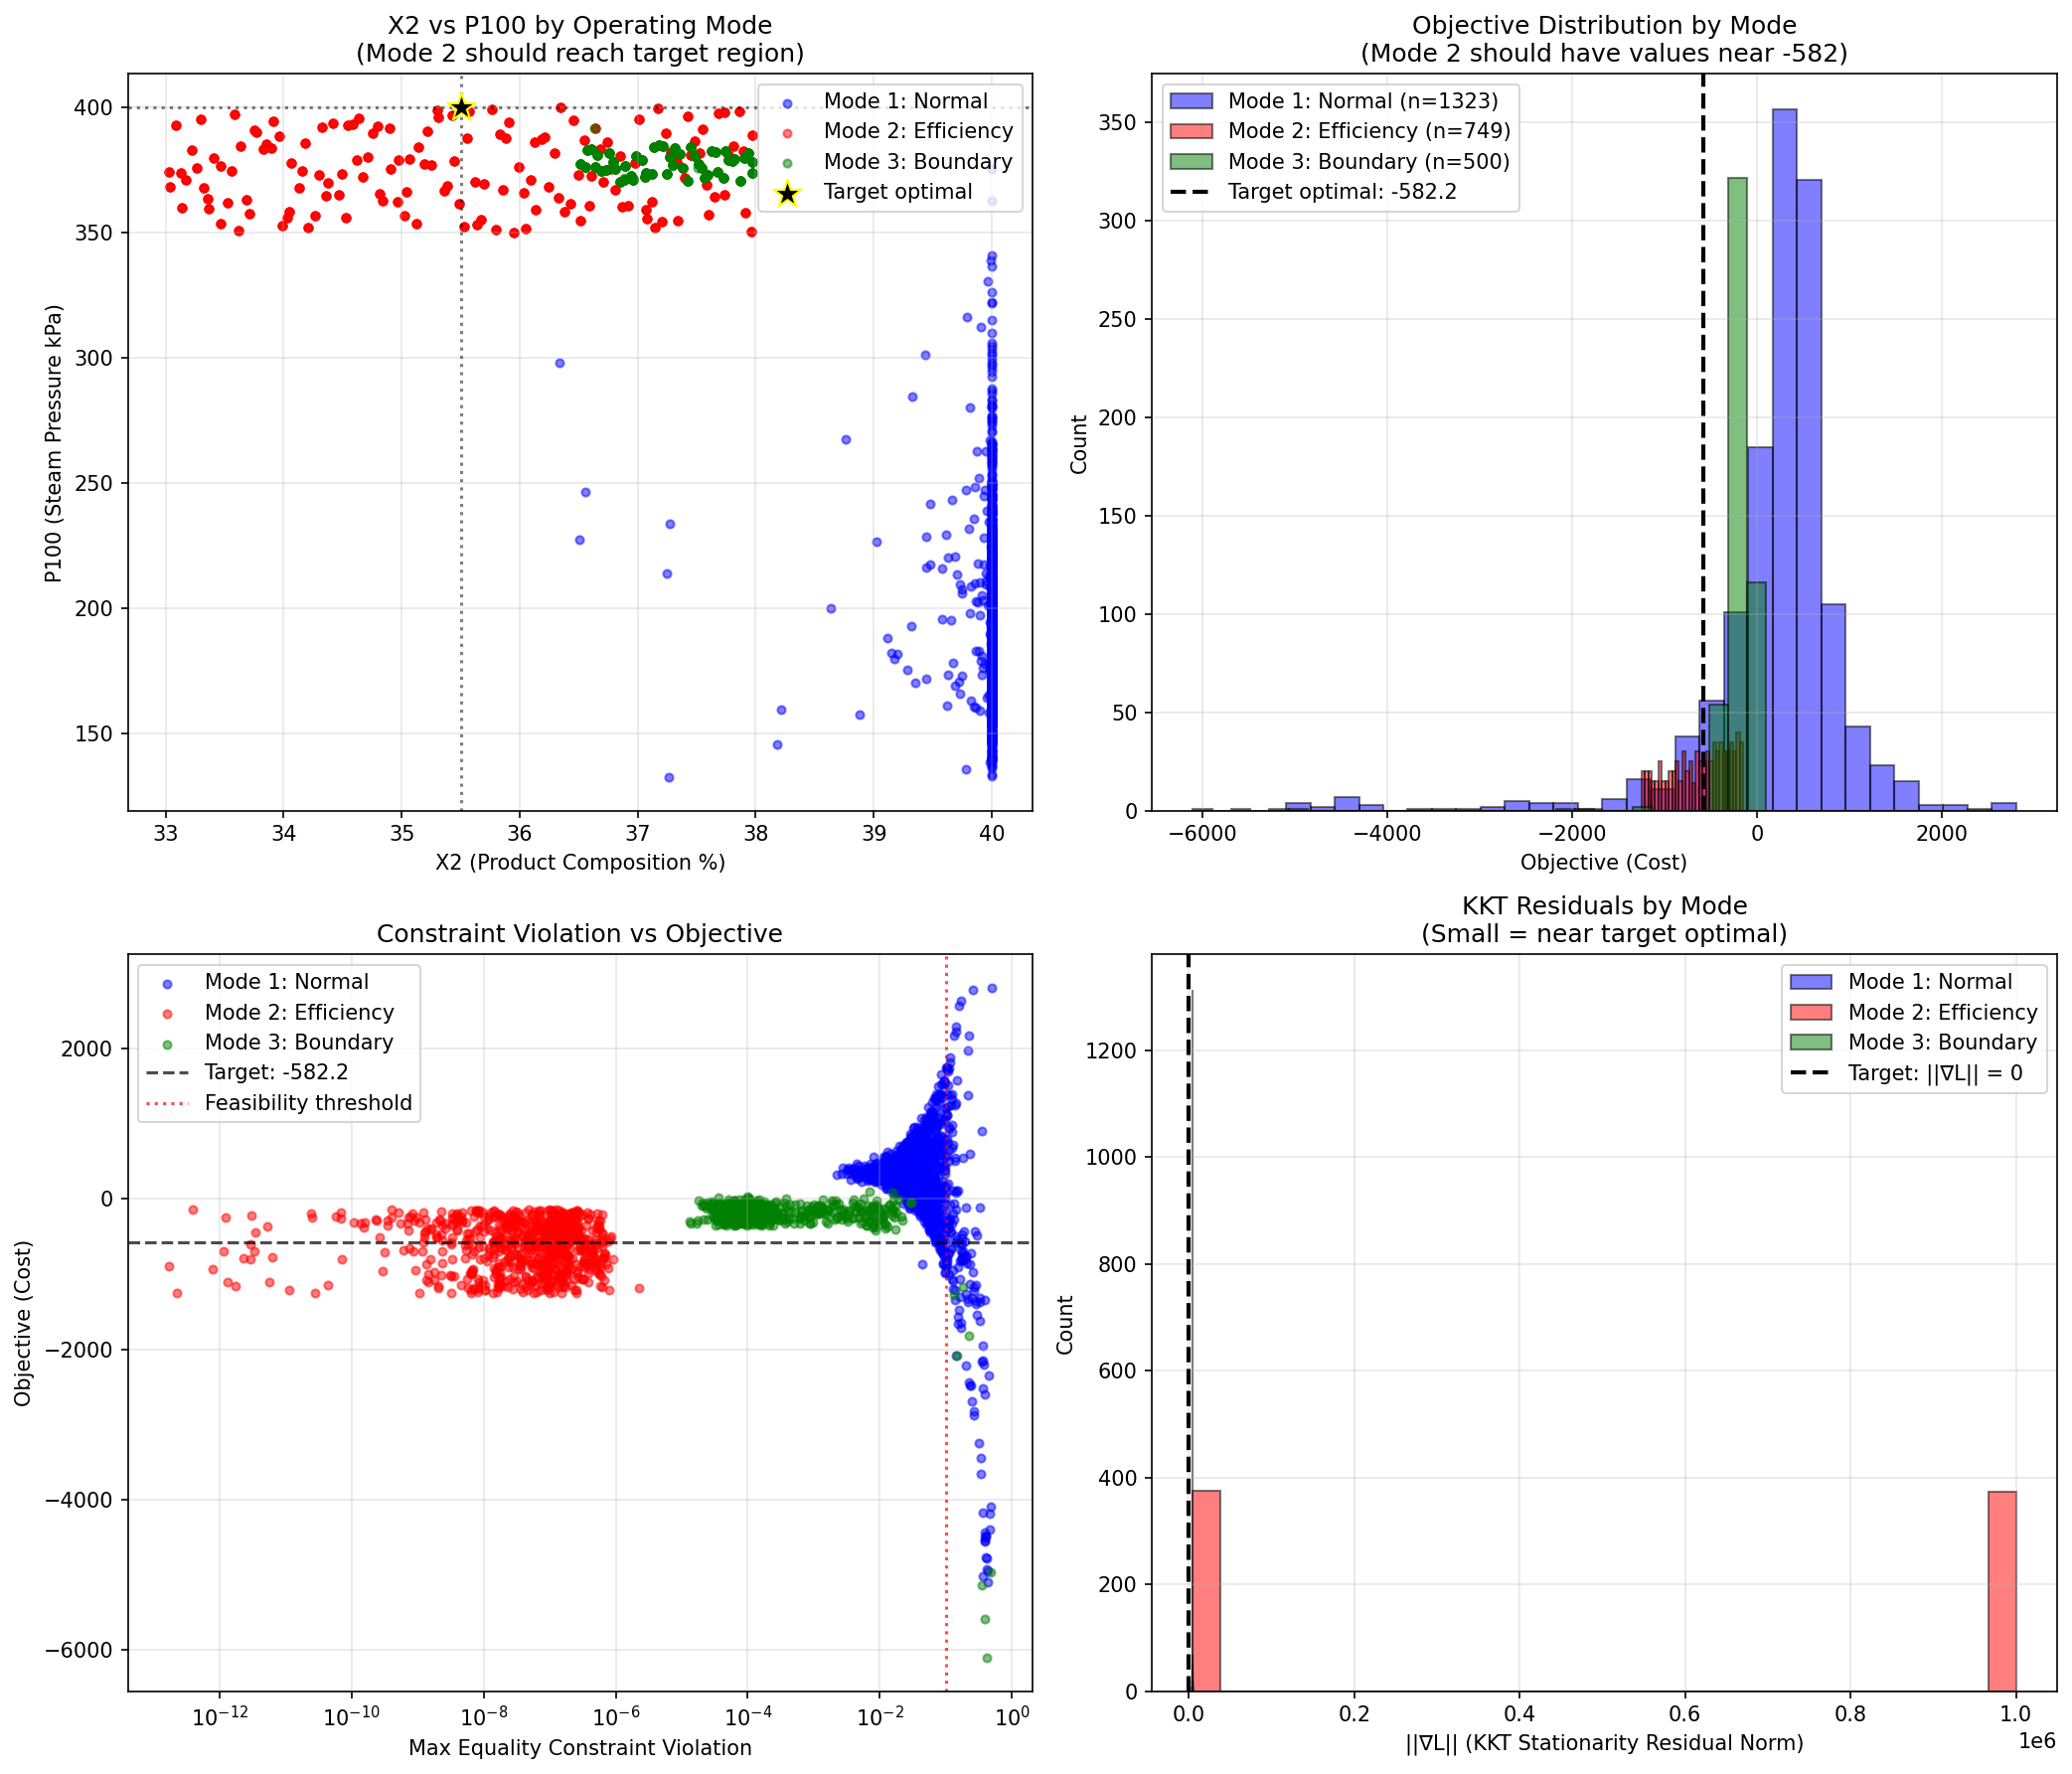


Key observations:
1. Mode 1 (Normal): Diverse feasibility data, objectives spread widely
2. Mode 2 (Efficiency): Cost-optimized data, should have objectives near -582.2
3. Mode 3 (Boundary): Data near constraint boundaries (X2≈35.5, P100≈400.0)

Mode 2 data should naturally reach the target optimal region!


In [137]:
# Visualize training data from all three modes
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Color mapping for modes
mode_colors = {
    'Mode 1: Normal': 'blue',
    'Mode 2: Efficiency': 'red', 
    'Mode 3: Boundary': 'green'
}
colors = [mode_colors[m] for m in mode_labels]

# 1. X2 vs P100 by mode (KEY PLOT - shows coverage)
ax = axes[0, 0]
for mode_name, color in mode_colors.items():
    mask = [m == mode_name for m in mode_labels]
    if any(mask):
        ax.scatter(X_solutions[mask, 5], X_solutions[mask, 11], 
                  c=color, alpha=0.5, s=15, label=mode_name)
ax.scatter([scipy_solution[5]], [scipy_solution[11]], c='black', s=200, 
          marker='*', label='Target optimal', zorder=10, edgecolors='yellow', linewidths=1)
ax.axhline(TARGET_P100_MAX, color='k', ls=':', alpha=0.5)
ax.axvline(TARGET_X2_MIN, color='k', ls=':', alpha=0.5)
ax.set_xlabel('X2 (Product Composition %)')
ax.set_ylabel('P100 (Steam Pressure kPa)')
ax.set_title('X2 vs P100 by Operating Mode\n(Mode 2 should reach target region)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# 2. Objective distribution by mode
ax = axes[0, 1]
for i, (mode_name, color) in enumerate(mode_colors.items()):
    mask = [m == mode_name for m in mode_labels]
    if any(mask):
        ax.hist(obj_solutions[mask], bins=30, alpha=0.5, color=color, 
               label=f'{mode_name} (n={sum(mask)})', edgecolor='black')
ax.axvline(scipy_cost, color='black', ls='--', lw=2, label=f'Target optimal: {scipy_cost:.1f}')
ax.set_xlabel('Objective (Cost)')
ax.set_ylabel('Count')
ax.set_title('Objective Distribution by Mode\n(Mode 2 should have values near -582)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Constraint violation vs Objective
ax = axes[1, 0]
for mode_name, color in mode_colors.items():
    mask = [m == mode_name for m in mode_labels]
    if any(mask):
        ax.scatter(viol_solutions[mask], obj_solutions[mask], 
                  c=color, alpha=0.5, s=15, label=mode_name)
ax.axhline(scipy_cost, color='black', ls='--', alpha=0.7, label=f'Target: {scipy_cost:.1f}')
ax.axvline(0.1, color='red', ls=':', alpha=0.7, label='Feasibility threshold')
ax.set_xlabel('Max Equality Constraint Violation')
ax.set_ylabel('Objective (Cost)')
ax.set_title('Constraint Violation vs Objective')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. KKT residual norm by mode
ax = axes[1, 1]
grad_norms = np.linalg.norm(grad_solutions, axis=1)
for mode_name, color in mode_colors.items():
    mask = [m == mode_name for m in mode_labels]
    if any(mask):
        ax.hist(grad_norms[mask], bins=30, alpha=0.5, color=color, 
               label=mode_name, edgecolor='black')
ax.axvline(0, color='black', ls='--', lw=2, label='Target: ||∇L|| = 0')
ax.set_xlabel('||∇L|| (KKT Stationarity Residual Norm)')
ax.set_ylabel('Count')
ax.set_title('KKT Residuals by Mode\n(Small = near target optimal)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaporator_operating_modes_training_data.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey observations:")
print(f"1. Mode 1 (Normal): Diverse feasibility data, objectives spread widely")
print(f"2. Mode 2 (Efficiency): Cost-optimized data, should have objectives near {scipy_cost:.1f}")
print(f"3. Mode 3 (Boundary): Data near constraint boundaries (X2≈{TARGET_X2_MIN}, P100≈{TARGET_P100_MAX})")
print(f"\nMode 2 data should naturally reach the target optimal region!")

## Prepare Training Data for Generative Models

Training data includes:
- **x**: 16 decision variables
- **e**: 12 equality constraint residuals
- **∇L**: 16 stationarity residuals (gradient of barrier Lagrangian)

Total: **44 dimensions**

Conditioning will be on **[e = 0, ∇L = 0]** (28 conditions).

In [138]:
# Filter to near-feasible samples (for equality constraints)
threshold = 0.1
feasible_mask = viol_solutions < threshold

X_train = X_solutions[feasible_mask]
obj_train = obj_solutions[feasible_mask]
eq_train = eq_solutions[feasible_mask]
grad_train = grad_solutions[feasible_mask]  # KKT residuals for TARGET problem

print(f"Filtered to {len(X_train)} near-feasible training samples (threshold={threshold})")
print(f"\nTraining data dimensions:")
print(f"  x: {X_train.shape} (decision variables)")
print(f"  e: {eq_train.shape} (equality residuals)")
print(f"  ∇L: {grad_train.shape} (KKT stationarity residuals for TARGET)")
print(f"\nObjective range in training data: [{obj_train.min():.2f}, {obj_train.max():.2f}]")
print(f"(This is DIVERSE - not all at optimal {scipy_cost:.2f})")
print(f"\nX2 range: [{X_train[:, 5].min():.2f}, {X_train[:, 5].max():.2f}] (target: {TARGET_X2_MIN})")
print(f"P100 range: [{X_train[:, 11].min():.2f}, {X_train[:, 11].max():.2f}] (target: {TARGET_P100_MAX})")

Filtered to 2393 near-feasible training samples (threshold=0.1)

Training data dimensions:
  x: (2393, 16) (decision variables)
  e: (2393, 12) (equality residuals)
  ∇L: (2393, 16) (KKT stationarity residuals for TARGET)

Objective range in training data: [-1248.49, 1658.45]
(This is DIVERSE - not all at optimal -582.23)

X2 range: [33.03, 40.00] (target: 35.5)
P100 range: [133.46, 399.91] (target: 400.0)


---

# Part 1: Gaussian Mixture Model (GMM) Approach

**KKT-Style Approach:**
- Build GMM on joint distribution of **(x, e, ∇L)** (44 dimensions)
- Condition on **[e = 0, ∇L = 0]** (28 conditions)
- This selects points that satisfy BOTH feasibility AND optimality
- Sample and select best solutions

In [139]:
# Build GMM on (x, e, ∇L)
# Columns: [x1, ..., x16, eq1, ..., eq12, grad1, ..., grad16] = 44 columns

data_gmm = np.hstack([X_train, eq_train, grad_train])
print(f"GMM training data shape: {data_gmm.shape}")
print(f"  - x: columns 0-15 (decision variables)")
print(f"  - e: columns 16-27 (equality residuals)")
print(f"  - ∇L: columns 28-43 (stationarity residuals)")

# Fit GMM
print("\nTraining GMM...")
gmm, info = best_gmm(data_gmm, max_components=50, verbose=True, patience=15)
print(f"\nBest model: {info['best_k']} components")

GMM training data shape: (2393, 44)
  - x: columns 0-15 (decision variables)
  - e: columns 16-27 (equality residuals)
  - ∇L: columns 28-43 (stationarity residuals)

Training GMM...
k=1: BIC=-635334.6 *
k=2: BIC=-741884.6 *
k=3: BIC=-823335.5 *
k=4: BIC=-832916.7 *
k=5: BIC=-855747.5 *
k=6: BIC=-856761.5 *
k=7: BIC=-857759.4 *
k=8: BIC=-845810.1
k=9: BIC=-843680.0
k=10: BIC=-835930.0
k=11: BIC=-836999.4
k=12: BIC=-828289.2
k=13: BIC=-819839.6
k=14: BIC=-818213.0
k=15: BIC=-810696.1
k=16: BIC=-804282.6
k=17: BIC=-801633.0
k=18: BIC=-787352.7
k=19: BIC=-782723.1
k=20: BIC=-777674.1
k=21: BIC=-773262.8
k=22: BIC=-762556.0
Early stopping at k=22

Best model: 7 components


In [140]:
# Condition on [e = 0, ∇L = 0] for TARGET problem
# This selects points that satisfy KKT conditions for the TARGET problem
constraint_cols = list(range(16, 44))  # e (12) + ∇L (16) = 28 columns
zero_constraints = np.zeros(28)

print(f"Conditioning on {len(constraint_cols)} columns: [e = 0, ∇L = 0]")
print(f"  - e: columns 16-27 (12 equality constraints)")
print(f"  - ∇L: columns 28-43 (16 KKT stationarity conditions for TARGET)")
print(f"\nThis selects points optimal for TARGET problem:")
print(f"  X2 >= {TARGET_X2_MIN}, P100 <= {TARGET_P100_MAX}")

# Get conditional GMM
cond_gmm = gmm.condition(constraint_cols, zero_constraints)

# Sample from conditional distribution
n_gmm_samples = 5000
gmm_samples = cond_gmm.sample(n_gmm_samples)

# Clip to TARGET problem bounds
lb_clip = lb_base.copy()
ub_clip = ub_base.copy()
lb_clip[5] = TARGET_X2_MIN
gmm_samples = np.clip(gmm_samples, lb_clip, ub_clip)

print(f"\nGenerated {n_gmm_samples} samples from GMM (conditioned on TARGET KKT=0)")

Conditioning on 28 columns: [e = 0, ∇L = 0]
  - e: columns 16-27 (12 equality constraints)
  - ∇L: columns 28-43 (16 KKT stationarity conditions for TARGET)

This selects points optimal for TARGET problem:
  X2 >= 35.5, P100 <= 400.0

Generated 5000 samples from GMM (conditioned on TARGET KKT=0)


In [141]:
# Evaluate GMM samples
gmm_objectives = np.array([objective(x) for x in gmm_samples])
gmm_violations = np.array([max_constraint_violation(x) for x in gmm_samples])

print("GMM Sample Statistics:")
print(f"  Objective: mean={gmm_objectives.mean():.2f}, min={gmm_objectives.min():.2f}, max={gmm_objectives.max():.2f}")
print(f"  Constraint violation: mean={gmm_violations.mean():.4e}, min={gmm_violations.min():.4e}")
print(f"  Samples with violation < 0.1: {(gmm_violations < 0.1).sum()}")
print(f"  Samples with violation < 0.01: {(gmm_violations < 0.01).sum()}")

GMM Sample Statistics:
  Objective: mean=-215.87, min=-449.52, max=694.03
  Constraint violation: mean=5.7734e+00, min=3.2504e-02
  Samples with violation < 0.1: 8
  Samples with violation < 0.01: 0


In [142]:
# Select best GMM sample (lowest objective among near-feasible)
feasible_gmm = gmm_violations < 0.1
if feasible_gmm.sum() > 0:
    feasible_idx = np.where(feasible_gmm)[0]
    best_idx = feasible_idx[np.argmin(gmm_objectives[feasible_gmm])]
    print(f"Found {feasible_gmm.sum()} near-feasible samples")
else:
    best_idx = np.argmin(gmm_violations)
    print("Warning: No near-feasible samples found, using lowest violation")

x_gmm_best = gmm_samples[best_idx]

print("\nGMM Best Sample (conditioned on TARGET KKT=0):")
print(f"  Objective: {objective(x_gmm_best):.4f} (target: {scipy_cost:.4f})")
print(f"  Max equality constraint violation: {max_constraint_violation(x_gmm_best):.4e}")
print(f"\n  Inequality constraint satisfaction (TARGET):")
ineq_check = check_inequalities(x_gmm_best, TARGET_X2_MIN, TARGET_P100_MAX)
for name, val in ineq_check.items():
    status = 'OK' if val >= 0 else 'VIOLATED'
    print(f"    {name}: {val:.4f} ({status})")

print(f"\n  Comparison to target optimal:")
print(f"    X2:   GMM={x_gmm_best[5]:.2f}, Target={scipy_solution[5]:.2f}")
print(f"    P100: GMM={x_gmm_best[11]:.2f}, Target={scipy_solution[11]:.2f}")

Found 8 near-feasible samples

GMM Best Sample (conditioned on TARGET KKT=0):
  Objective: -285.5538 (target: -582.2331)
  Max equality constraint violation: 3.2504e-02

  Inequality constraint satisfaction (TARGET):
    X2 >= X2_min: 1.4515 (OK)
    P2 >= 40: 18.2968 (OK)
    P2 <= 80: 21.7032 (OK)
    P100 <= P100_max: 31.5962 (OK)

  Comparison to target optimal:
    X2:   GMM=36.95, Target=35.50
    P100: GMM=368.40, Target=400.00


---

# Part 2: Flow Matching Approach

**KKT-Style Approach:**
- Train flow matching to generate decision variables **x** conditioned on **(e, ∇L)**
- Condition on **[e = 0, ∇L = 0]** (28 conditions)
- This selects points that satisfy BOTH feasibility AND optimality
- Sample and select best solutions

In [143]:
# Prepare training data for Flow Matching
# x: decision variables (what we want to generate)
# c: [e, ∇L] (conditions)
x_fm_train = X_train.astype(np.float32)
c_fm_train = np.hstack([eq_train, grad_train]).astype(np.float32)

print(f"Flow Matching training data:")
print(f"  x shape: {x_fm_train.shape} (decision variables - what we generate)")
print(f"  c shape: {c_fm_train.shape} (conditions: [e, ∇L])")
print(f"    - e: columns 0-11 (12 equality residuals)")
print(f"    - ∇L: columns 12-27 (16 stationarity residuals)")

Flow Matching training data:
  x shape: (2393, 16) (decision variables - what we generate)
  c shape: (2393, 28) (conditions: [e, ∇L])
    - e: columns 0-11 (12 equality residuals)
    - ∇L: columns 12-27 (16 stationarity residuals)


In [144]:
# Train Flow Matching model
fm = ConditionalFlowMatching(
    x_dim=16,     # 16 decision variables (what we generate)
    c_dim=28,     # 28 conditions: 12 equality residuals + 16 stationarity residuals
    hidden_dim=512,
    n_layers=6,
    sigma_min=0.001
)

print("Training Flow Matching model...")
print(f"  x_dim: 16 (decision variables)")
print(f"  c_dim: 28 (conditions: [e, ∇L])")
history = fm.fit(
    x_fm_train, 
    c_fm_train, 
    epochs=3000,
    batch_size=256, 
    lr=5e-4,
    verbose=True,
    eval_every=100
)

Training Flow Matching model...
  x_dim: 16 (decision variables)
  c_dim: 28 (conditions: [e, ∇L])


Training: 100%|██████████| 3000/3000 [06:12<00:00,  8.06it/s, MAE=1.5015, R2=0.9452, loss=0.1015]


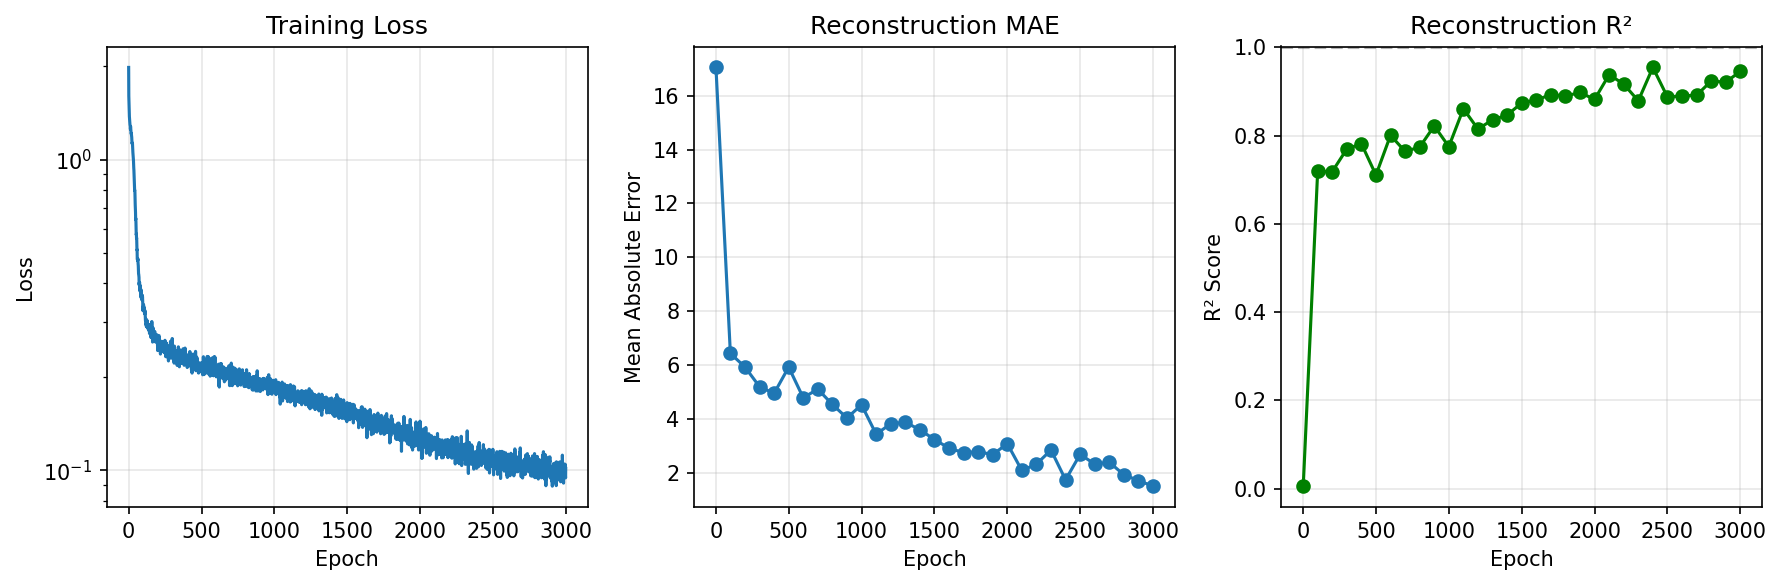

Final Loss: 0.101545
Final MAE:  1.501508
Final R²:   0.945178


In [145]:
# Plot learning curves
fm.plot_learning_curves()

In [146]:
# Generate samples conditioned on [e = 0, ∇L = 0] for TARGET problem
target_conditions = np.zeros(28)  # e=0 (12) + ∇L=0 (16) for TARGET

print(f"Conditioning on 28-dimensional target: [e=0, ∇L=0] for TARGET")
print(f"  Target: X2 >= {TARGET_X2_MIN}, P100 <= {TARGET_P100_MAX}")

n_fm_samples = 5000
fm_samples = fm.sample(c_values=[target_conditions], n_samples=n_fm_samples, n_steps=200)

# Clip to TARGET problem bounds
fm_samples = np.clip(fm_samples, lb_clip, ub_clip)

print(f"\nGenerated {n_fm_samples} samples from Flow Matching (conditioned on TARGET KKT=0)")

Conditioning on 28-dimensional target: [e=0, ∇L=0] for TARGET
  Target: X2 >= 35.5, P100 <= 400.0

Generated 5000 samples from Flow Matching (conditioned on TARGET KKT=0)


In [147]:
# Evaluate Flow Matching samples
fm_objectives = np.array([objective(x) for x in fm_samples])
fm_violations = np.array([max_constraint_violation(x) for x in fm_samples])

print("Flow Matching Sample Statistics:")
print(f"  Objective: mean={fm_objectives.mean():.2f}, min={fm_objectives.min():.2f}, max={fm_objectives.max():.2f}")
print(f"  Constraint violation: mean={fm_violations.mean():.4e}, min={fm_violations.min():.4e}")
print(f"  Samples with violation < 0.1: {(fm_violations < 0.1).sum()}")
print(f"  Samples with violation < 0.01: {(fm_violations < 0.01).sum()}")

Flow Matching Sample Statistics:
  Objective: mean=-83979.64, min=-83979.64, max=-83979.64
  Constraint violation: mean=4.9895e+02, min=4.9895e+02
  Samples with violation < 0.1: 0
  Samples with violation < 0.01: 0


In [148]:
# Select best Flow Matching sample
feasible_fm = fm_violations < 0.1
if feasible_fm.sum() > 0:
    feasible_idx = np.where(feasible_fm)[0]
    best_idx = feasible_idx[np.argmin(fm_objectives[feasible_fm])]
    print(f"Found {feasible_fm.sum()} near-feasible samples")
else:
    best_idx = np.argmin(fm_violations)
    print("Warning: No near-feasible samples found, using lowest violation")

x_fm_best = fm_samples[best_idx]

print("\nFlow Matching Best Sample (conditioned on TARGET KKT=0):")
print(f"  Objective: {objective(x_fm_best):.4f} (target: {scipy_cost:.4f})")
print(f"  Max equality constraint violation: {max_constraint_violation(x_fm_best):.4e}")
print(f"\n  Inequality constraint satisfaction (TARGET):")
ineq_check = check_inequalities(x_fm_best, TARGET_X2_MIN, TARGET_P100_MAX)
for name, val in ineq_check.items():
    status = 'OK' if val >= 0 else 'VIOLATED'
    print(f"    {name}: {val:.4f} ({status})")

print(f"\n  Comparison to target optimal:")
print(f"    X2:   FM={x_fm_best[5]:.2f}, Target={scipy_solution[5]:.2f}")
print(f"    P100: FM={x_fm_best[11]:.2f}, Target={scipy_solution[11]:.2f}")


Flow Matching Best Sample (conditioned on TARGET KKT=0):
  Objective: -83979.6391 (target: -582.2331)
  Max equality constraint violation: 4.9895e+02

  Inequality constraint satisfaction (TARGET):
    X2 >= X2_min: 4.5000 (OK)
    P2 >= 40: 40.0000 (OK)
    P2 <= 80: 0.0000 (OK)
    P100 <= P100_max: 0.0000 (OK)

  Comparison to target optimal:
    X2:   FM=40.00, Target=35.50
    P100: FM=400.00, Target=400.00


---

# Final Comparison

In [149]:
# Summary comparison
print("\n" + "=" * 90)
print("FINAL COMPARISON: GMM vs Flow Matching vs Scipy")
print("=" * 90)

print("\n" + "-" * 90)
print("GENERATIVE MODEL OUTPUTS:")
print("-" * 90)
print(f"{'Method':<20} {'Objective':>15} {'Max Eq Viol':>15} {'Feasible?':>12}")
print("-" * 65)
print(f"{'GMM Best':<20} {objective(x_gmm_best):>15.4f} {max_constraint_violation(x_gmm_best):>15.4e} {'Yes' if max_constraint_violation(x_gmm_best) < 0.01 else 'No':>12}")
print(f"{'Flow Matching Best':<20} {objective(x_fm_best):>15.4f} {max_constraint_violation(x_fm_best):>15.4e} {'Yes' if max_constraint_violation(x_fm_best) < 0.01 else 'No':>12}")

print("\n" + "-" * 90)
print("REFERENCE SOLUTIONS:")
print("-" * 90)
print(f"{'Method':<20} {'Objective':>15} {'Max Eq Viol':>15} {'Feasible?':>12}")
print("-" * 65)
print(f"{'Scipy (optimal)':<20} {scipy_cost:>15.4f} {max_constraint_violation(scipy_solution):>15.4e} {'Yes' if max_constraint_violation(scipy_solution) < 0.01 else 'No':>12}")
print(f"{'Literature':<20} {objective(x_opt_lit):>15.4f} {max_constraint_violation(x_opt_lit):>15.4e} {'Yes' if max_constraint_violation(x_opt_lit) < 0.01 else 'No':>12}")

print("\n" + "-" * 90)
print("TRAINING DATA STATISTICS:")
print("-" * 90)
print(f"Total training samples: {len(X_train)}")
print(f"Objective range: [{obj_train.min():.2f}, {obj_train.max():.2f}]")
print(f"Best in training data: {obj_train.min():.4f}")
print(f"\nNote: Training data is DIVERSE (not all at optimum)")
print(f"      Barrier method ensured inequality constraints during data generation")


FINAL COMPARISON: GMM vs Flow Matching vs Scipy

------------------------------------------------------------------------------------------
GENERATIVE MODEL OUTPUTS:
------------------------------------------------------------------------------------------
Method                     Objective     Max Eq Viol    Feasible?
-----------------------------------------------------------------
GMM Best                   -285.5538      3.2504e-02           No
Flow Matching Best       -83979.6391      4.9895e+02           No

------------------------------------------------------------------------------------------
REFERENCE SOLUTIONS:
------------------------------------------------------------------------------------------
Method                     Objective     Max Eq Viol    Feasible?
-----------------------------------------------------------------
Scipy (optimal)            -582.2331      5.8316e-07          Yes
Literature                 -583.9739      1.4797e-03          Yes

---------

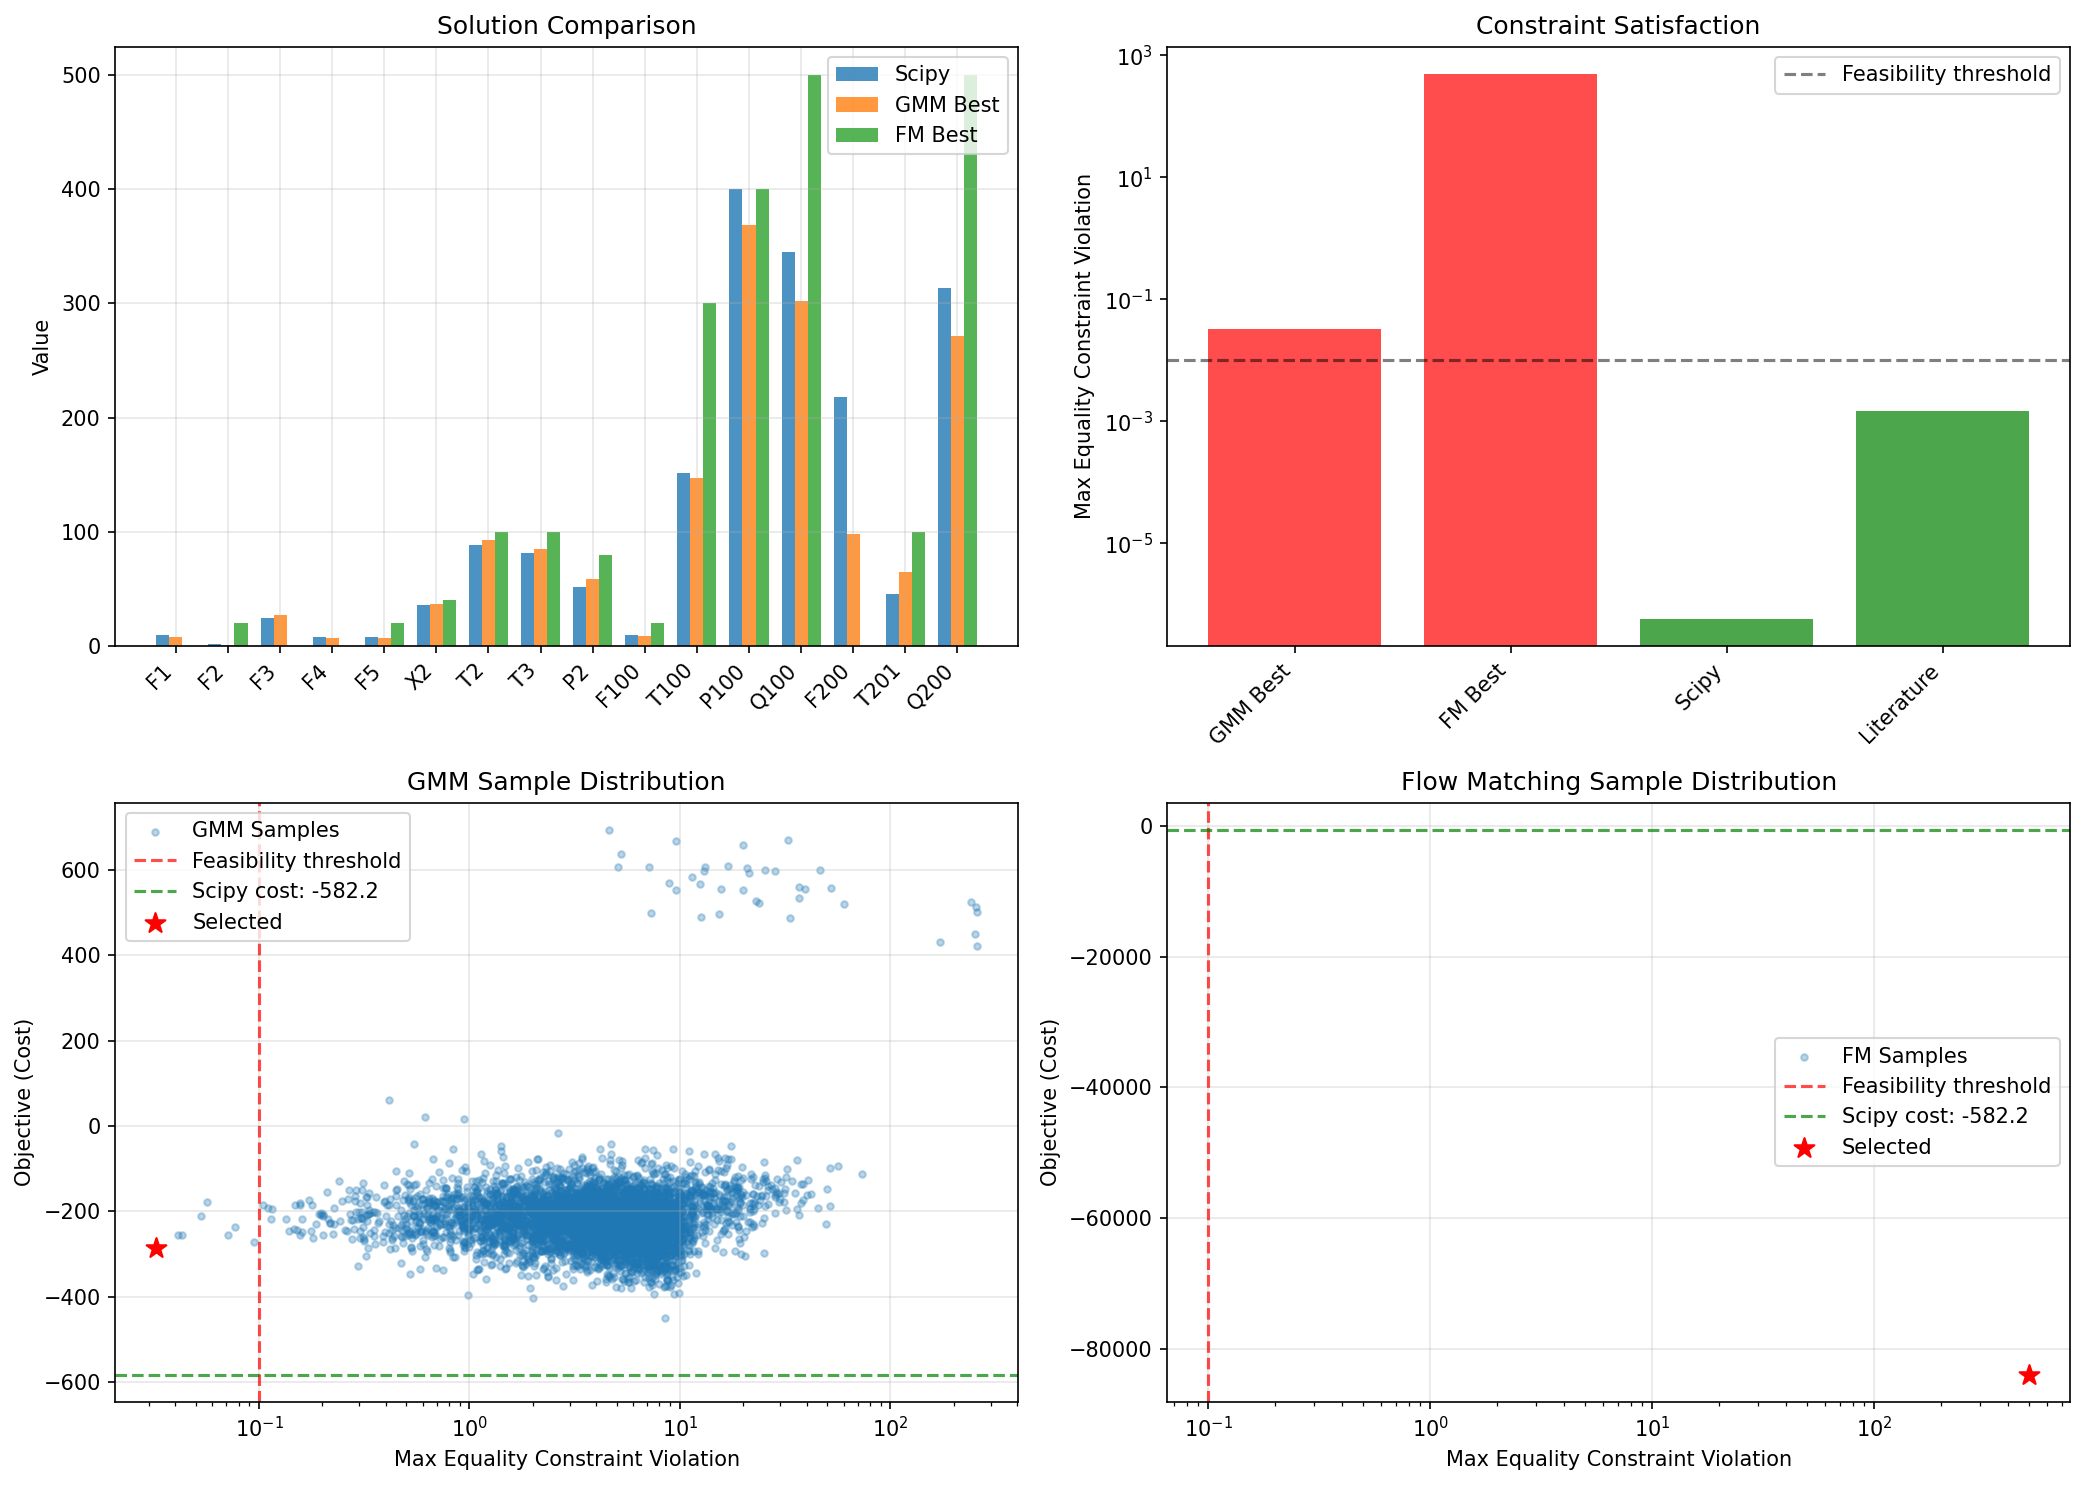


Saved: evaporator_barrier_comparison.png


In [150]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart comparing solutions
ax = axes[0, 0]
x_pos = np.arange(len(NAMES))
width = 0.25

ax.bar(x_pos - width, scipy_solution, width, label='Scipy', alpha=0.8)
ax.bar(x_pos, x_gmm_best, width, label='GMM Best', alpha=0.8)
ax.bar(x_pos + width, x_fm_best, width, label='FM Best', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(NAMES, rotation=45, ha='right')
ax.set_ylabel('Value')
ax.set_title('Solution Comparison')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# 2. Constraint satisfaction
ax = axes[0, 1]
methods = ['GMM Best', 'FM Best', 'Scipy', 'Literature']
violations = [
    max_constraint_violation(x_gmm_best),
    max_constraint_violation(x_fm_best),
    max_constraint_violation(scipy_solution),
    max_constraint_violation(x_opt_lit)
]
colors = ['red' if v > 0.01 else 'green' for v in violations]
ax.bar(methods, violations, color=colors, alpha=0.7)
ax.axhline(0.01, color='k', ls='--', alpha=0.5, label='Feasibility threshold')
ax.set_ylabel('Max Equality Constraint Violation')
ax.set_title('Constraint Satisfaction')
ax.set_yscale('log')
ax.legend()
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. GMM sample distribution
ax = axes[1, 0]
ax.scatter(gmm_violations, gmm_objectives, alpha=0.3, s=10, label='GMM Samples')
ax.axvline(0.1, color='r', ls='--', alpha=0.7, label='Feasibility threshold')
ax.axhline(scipy_cost, color='g', ls='--', alpha=0.7, label=f'Scipy cost: {scipy_cost:.1f}')
ax.scatter([max_constraint_violation(x_gmm_best)], [objective(x_gmm_best)], 
           s=100, c='red', marker='*', zorder=5, label='Selected')
ax.set_xlabel('Max Equality Constraint Violation')
ax.set_ylabel('Objective (Cost)')
ax.set_title('GMM Sample Distribution')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. FM sample distribution
ax = axes[1, 1]
ax.scatter(fm_violations, fm_objectives, alpha=0.3, s=10, label='FM Samples')
ax.axvline(0.1, color='r', ls='--', alpha=0.7, label='Feasibility threshold')
ax.axhline(scipy_cost, color='g', ls='--', alpha=0.7, label=f'Scipy cost: {scipy_cost:.1f}')
ax.scatter([max_constraint_violation(x_fm_best)], [objective(x_fm_best)], 
           s=100, c='red', marker='*', zorder=5, label='Selected')
ax.set_xlabel('Max Equality Constraint Violation')
ax.set_ylabel('Objective (Cost)')
ax.set_title('Flow Matching Sample Distribution')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaporator_barrier_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved: evaporator_barrier_comparison.png")

## Key Observations

**Diverse Data + KKT Conditioning Approach:**

1. **Diverse training data**: By solving FEASIBILITY problems with VARIED constraint bounds (via LHS), training data spans the feasible region like real plant historian data

2. **KKT residuals for TARGET problem**: For each diverse training point, we compute KKT residuals using the TARGET constraints (X2 >= 35.5, P100 <= 400)

3. **Conditioning on TARGET KKT = 0**: Points that happen to be near the TARGET optimal have small KKT residuals. Conditioning on [e=0, ∇L=0] selects these points.

4. **Barrier Lagrangian for TARGET**:
   $$L(x) = J(x) - \mu \left[ \log(X_2 - 35.5) + \log(P_2 - 40) + \log(80 - P_2) + \log(400 - P_{100}) \right]$$

5. **44-dimensional training data**: [x (16), e (12), ∇L (16)] captures decision variables, constraint satisfaction, and optimality conditions for TARGET

**Why this approach is realistic:**
- Real plant operations occur at various feasible points, not always at optimal
- Training data is DIVERSE (objectives spread across a wide range)
- KKT residuals tell us "how far from TARGET optimal" each point is
- Conditioning on KKT=0 selects the optimal region from the diverse set

**Key insight:**
- Previous approach: Conditioning only on e=0 → sampled "average" of diverse feasible points
- New approach: Conditioning on [e=0, ∇L=0] for TARGET → samples near TARGET optimal

In [151]:
# Final timing and memory report
_end_time = time.time()
_end_memory_mb = _process.memory_info().rss / (1024 * 1024)
_elapsed_seconds = _end_time - _start_time

print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION SUMMARY")
print("=" * 70)
print(f"Start time:      {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_start_time))}")
print(f"End time:        {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(_end_time))}")
print(f"Elapsed time:    {_elapsed_seconds:.2f} seconds ({_elapsed_seconds/60:.2f} minutes)")
print("-" * 70)
print(f"Initial memory:  {_start_memory_mb:.2f} MB")
print(f"Final memory:    {_end_memory_mb:.2f} MB")
print(f"Memory change:   {_end_memory_mb - _start_memory_mb:+.2f} MB")
print("=" * 70)


NOTEBOOK EXECUTION SUMMARY
Start time:      2026-01-18 21:35:25
End time:        2026-01-18 22:10:04
Elapsed time:    2079.32 seconds (34.66 minutes)
----------------------------------------------------------------------
Initial memory:  878.41 MB
Final memory:    584.75 MB
Memory change:   -293.66 MB
